In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def calculate_rmse(true, estimated):
    return np.sqrt(np.mean((np.array(true) - np.array(estimated))**2))

def plot_time_series(time, true, measured, filtered, ylabel, title, cov_history=None):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(time, true, 'k-', label='Истинное значение', linewidth=2)
    ax.plot(time, measured, 'b.', label='Измерение (с шумом)', alpha=0.5)
    ax.plot(time, filtered, 'r-', label='Оценка фильтра', linewidth=2)
    if cov_history is not None:
        ax2 = ax.twinx()
        ax2.plot(time[:len(cov_history)], cov_history, 'g--', label='Ковариация (P)', alpha=0.6)
        ax2.set_ylabel('Ковариация ошибки (P)', color='green')
        ax2.set_ylim(0, max(cov_history) * 1.2)
    ax.set_xlabel('Время (шаг)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_trajectory_2d(true_x, true_y, meas_x, meas_y, est_x, est_y, title):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(true_x, true_y, 'k-', label='Истинная траектория', lw=2)
    ax.plot(meas_x, meas_y, 'b.', label='Измерения (Датчик)', alpha=0.4)
    ax.plot(est_x, est_y, 'r-', label='Оценка фильтра', lw=2)
    ax.set_xlabel('X (м)')
    ax.set_ylabel('Y (м)')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

RMSE (Задача 1): 0.249


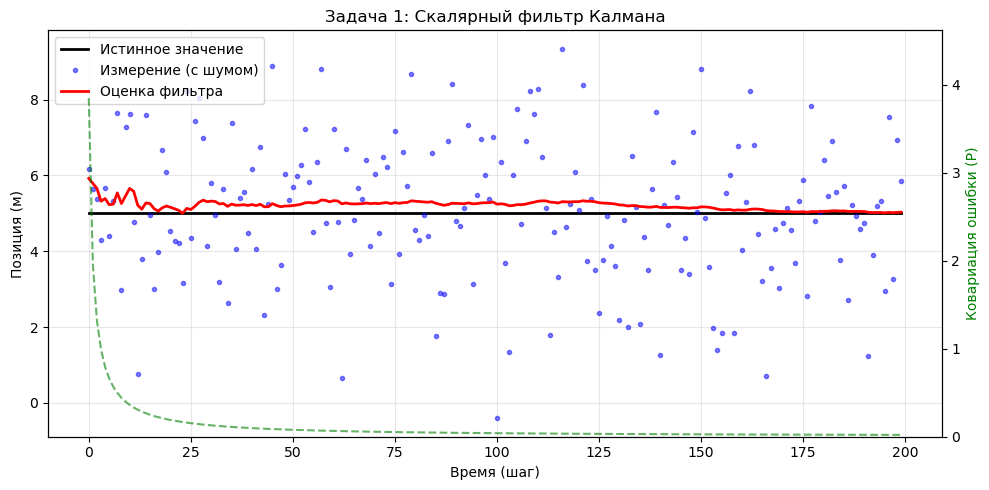

In [10]:
dt_1 = 0.05
N_1 = 200
true_pos_1 = 5.0 * np.ones(N_1)
noise_sigma_1 = 2.0
measurements_1 = true_pos_1 + np.random.normal(0, noise_sigma_1, N_1)
time_1 = np.arange(N_1)

# фильтр Каллмана первого порядка (измеряемая величина постоянна)
# идеально сглаживает координату и восстанавливает скорость, которую никто напрямую не измерял.

class KF1D:
    def __init__(self, q, r):
        self.Q = q # Дисперсия шума процесса
        self.R = r # Дисперсия шума измерений
        self.x = 0.0 # Текущая оценка состояния
        self.P = 100.0 # Дисперсия (ковариация) ошибки оценивания
        self.F = 1.0 # Коэффициент перехода состояний
        self.H = 1.0 # Коэффициент измерений
        self.P_history = []

    def predict(self):
        self.x = self.F * self.x
        self.P = self.F * self.P * self.F + self.Q

    def update(self, z):
        y = z - self.H * self.x
        S = self.H * self.P * self.H + self.R
        K = self.P * self.H / S
        self.x = self.x + K * y
        self.P = (1 - K * self.H) * self.P
        self.P_history.append(self.P)

Q_student_1 = 1e-5
R_student_1 = 4

kf_1 = KF1D(q=Q_student_1, r=R_student_1)
filtered_1 = []
for z in measurements_1:
    kf_1.predict()
    kf_1.update(z)
    filtered_1.append(kf_1.x)

rmse_1 = calculate_rmse(true_pos_1, filtered_1)
print(f"RMSE (Задача 1): {rmse_1:.3f}")
plot_time_series(time_1, true_pos_1, measurements_1, filtered_1,
                 "Позиция (м)", "Задача 1: Скалярный фильтр Калмана", kf_1.P_history)

RMSE позиции (Задача 2): 0.533


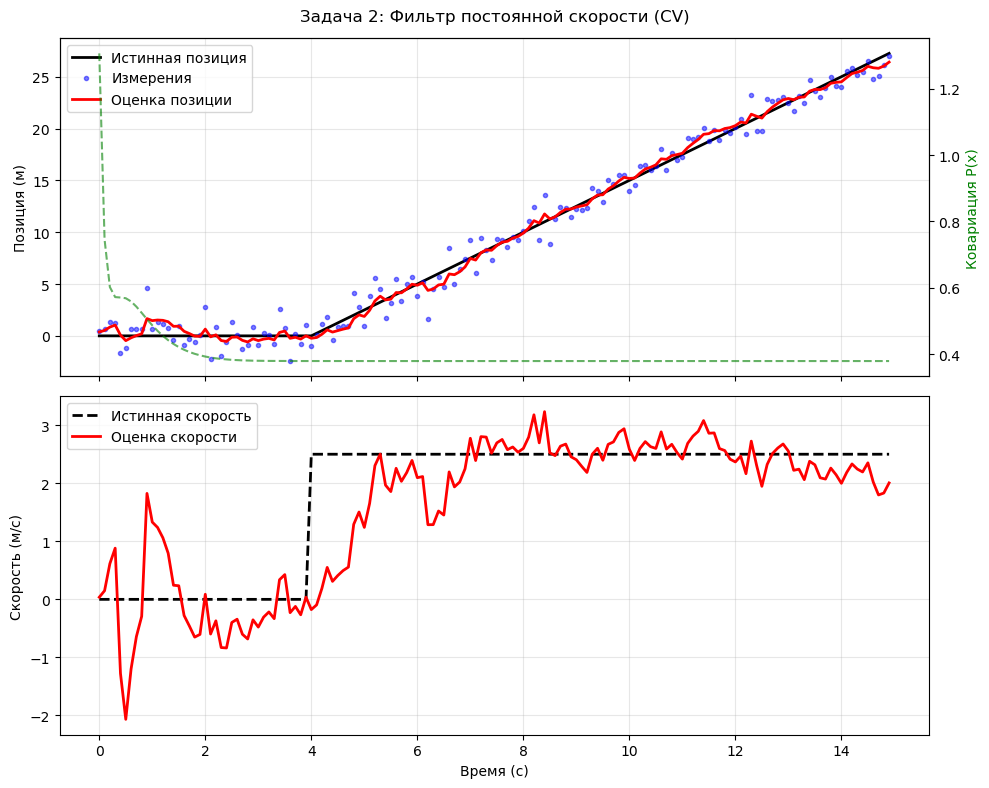

In [5]:
# фильтр Каллмана второго порядка
# восстановлении ненаблюдаемой величины (скорости) по зашумленным измерениям другой величины (координаты)

dt_2 = 0.1
N_2 = 150
time_2 = np.arange(N_2) * dt_2
true_pos_2 = np.zeros(N_2)
true_vel_2 = np.zeros(N_2)
true_vel_2[40:] = 2.5
for i in range(1, N_2):
    true_pos_2[i] = true_pos_2[i-1] + true_vel_2[i-1] * dt_2
noise_sigma_2 = 1.2
measurements_2 = true_pos_2 + np.random.normal(0, noise_sigma_2, N_2)

class KF_CV1D:
    def __init__(self, dt, q_pos, q_vel, r_pos):
        self.dt = dt
        self.F = np.array([[1, dt], [0, 1]])
        self.H = np.array([[1, 0]])
        self.Q = np.diag([q_pos, q_vel])
        self.R = np.array([[r_pos]])
        self.x = np.array([[0.0], [0.0]]) # [Позиция, Скорость]
        self.P = np.eye(2) * 10.0
        self.P_pos_history = []

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z):
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T / S[0, 0]
        self.x = self.x + K @ y
        self.P = (np.eye(2) - K @ self.H) @ self.P
        self.P_pos_history.append(self.P[0, 0])

q_pos_2 = 0.05
q_vel_2 = 0.1
r_pos_2 = 1.5

kf_2 = KF_CV1D(dt=dt_2, q_pos=q_pos_2, q_vel=q_vel_2, r_pos=r_pos_2)
filtered_pos_2 = []
filtered_vel_2 = []
for z in measurements_2:
    kf_2.predict()
    kf_2.update(np.array([[z]]))
    filtered_pos_2.append(kf_2.x[0, 0])
    filtered_vel_2.append(kf_2.x[1, 0])

rmse_2 = calculate_rmse(true_pos_2, filtered_pos_2)
print(f"RMSE позиции (Задача 2): {rmse_2:.3f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(time_2, true_pos_2, 'k-', label='Истинная позиция', lw=2)
ax1.plot(time_2, measurements_2, 'b.', label='Измерения', alpha=0.5)
ax1.plot(time_2, filtered_pos_2, 'r-', label='Оценка позиции', lw=2)
ax1_twin = ax1.twinx()
ax1_twin.plot(time_2, kf_2.P_pos_history, 'g--', label='Ковариация P(x)', alpha=0.6)
ax1_twin.set_ylabel('Ковариация P(x)', color='green')
ax1.set_ylabel('Позиция (м)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax2.plot(time_2, true_vel_2, 'k--', label='Истинная скорость', lw=2)
ax2.plot(time_2, filtered_vel_2, 'r-', label='Оценка скорости', lw=2)
ax2.set_xlabel('Время (с)')
ax2.set_ylabel('Скорость (м/с)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.suptitle("Задача 2: Фильтр постоянной скорости (CV)")
plt.tight_layout()
plt.show()

RMSE X: 0.709 | Y: 0.681 | Total: 0.695


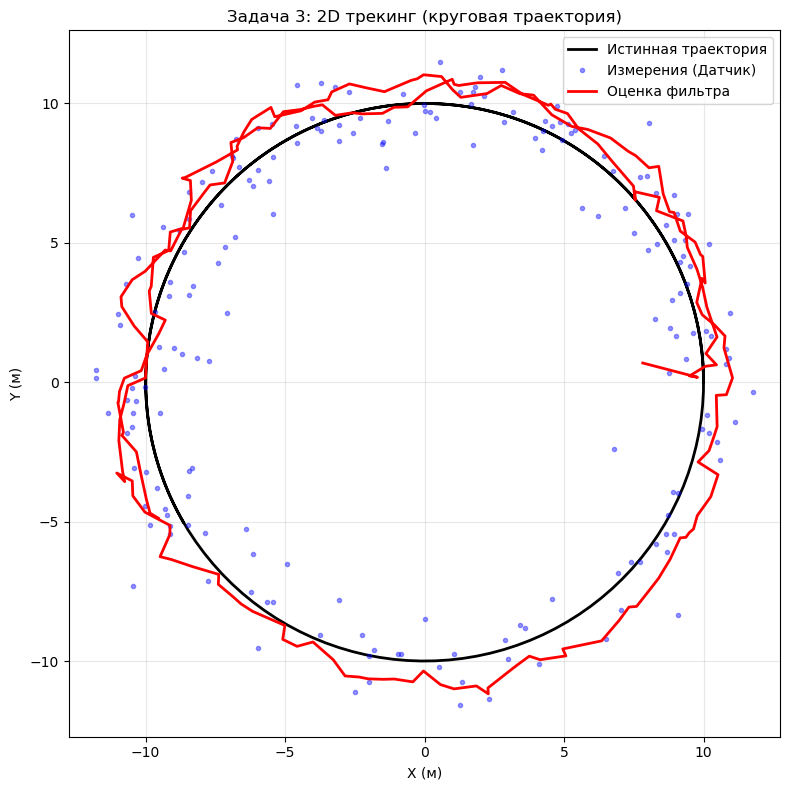

In [11]:


dt_3 = 0.1
N_3 = 200
t_3 = np.arange(N_3)
omega_3 = 0.05
true_x_3 = 10 * np.cos(omega_3 * t_3)
true_y_3 = 10 * np.sin(omega_3 * t_3)
noise_sigma_3 = 1.0
meas_x_3 = true_x_3 + np.random.normal(0, noise_sigma_3, N_3)
meas_y_3 = true_y_3 + np.random.normal(0, noise_sigma_3, N_3)

class KF_2D_CV:
    def __init__(self, dt, q, r):
        self.dt = dt
        F_block = np.array([[1, dt], [0, 1]])
        self.F = np.block([[F_block, np.zeros((2, 2))],
                           [np.zeros((2, 2)), F_block]])
        self.H = np.array([[1, 0, 0, 0],
                           [0, 0, 1, 0]])
        self.Q = np.eye(4) * q
        self.R = np.eye(2) * r
        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 5.0

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z):
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)
        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

q_3 = 0.05
r_3 = 1.0

kf_3 = KF_2D_CV(dt=dt_3, q=q_3, r=r_3)
est_x_3, est_y_3 = [], []
for mx, my in zip(meas_x_3, meas_y_3):
    kf_3.predict()
    kf_3.update(np.array([[mx], [my]]))
    est_x_3.append(kf_3.x[0, 0])
    est_y_3.append(kf_3.x[2, 0])

rmse_x3 = calculate_rmse(true_x_3, est_x_3)
rmse_y3 = calculate_rmse(true_y_3, est_y_3)
rmse_total3 = np.sqrt((rmse_x3**2 + rmse_y3**2) / 2)
print(f"RMSE X: {rmse_x3:.3f} | Y: {rmse_y3:.3f} | Total: {rmse_total3:.3f}")
plot_trajectory_2d(true_x_3, true_y_3, meas_x_3, meas_y_3, est_x_3, est_y_3,
                   "Задача 3: 2D трекинг (круговая траектория)")


ЗАДАНИЕ 4: Расширенный фильтр Калмана (EKF) – Автомобиль
Цель: Реализовать линеаризацию нелинейной кинематической модели.
RMSE X: 0.188 | Y: 0.203 | Total: 0.195


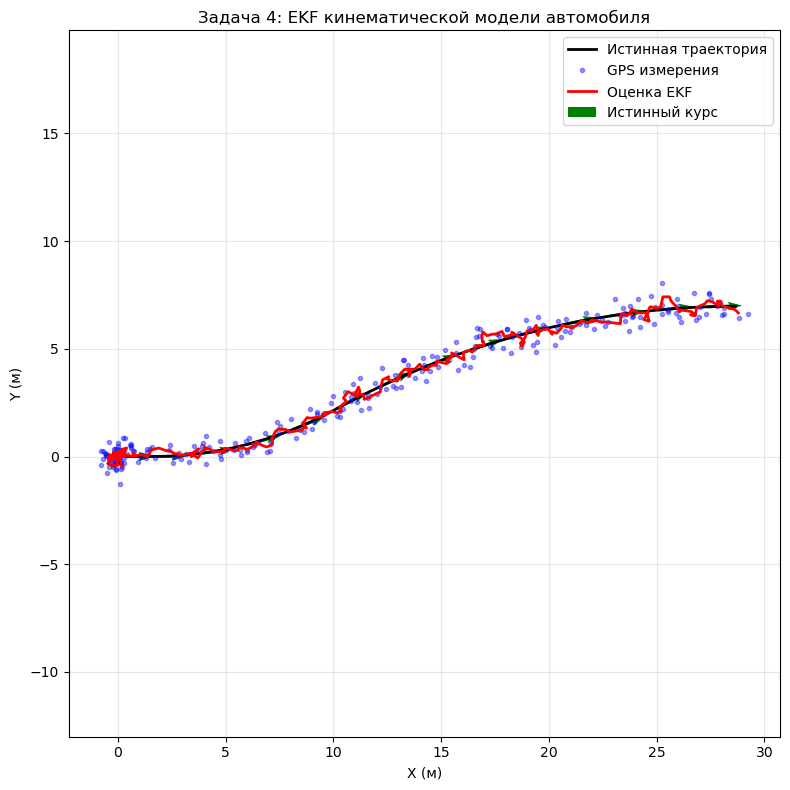

In [12]:
# четырехмерный линейный фильтр Калмана

import numpy as np
import matplotlib.pyplot as plt

# Фиксируем seed для воспроизводимости шума
np.random.seed(42)

def calculate_rmse(true, estimated):
    return np.sqrt(np.mean((np.array(true) - np.array(estimated))**2))

print("\nЗАДАНИЕ 4: Расширенный фильтр Калмана (EKF) – Автомобиль")
print("Цель: Реализовать линеаризацию нелинейной кинематической модели.")

# --- 1. Симуляция данных ---
dt_4 = 0.1
N_4 = 250
t_4 = np.arange(N_4)

# Инициализация массивов для истинной траектории
true_x_4, true_y_4, true_psi_4, true_v_4 = np.zeros(N_4), np.zeros(N_4), np.zeros(N_4), np.zeros(N_4)
true_v_4[50:] = 1.5  # Разгон до 1.5 м/с после 50-го шага

# Профиль изменения угла курса (рыскания) во времени
psi_profile_4 = np.zeros(N_4)
psi_profile_4[60:120] = np.linspace(0, 0.5, 60)   # Плавный поворот влево
psi_profile_4[120:] = np.linspace(0.5, 0, N_4-120) # Возврат к прямому движению

# Интегрирование нелинейной кинематической модели
for i in range(1, N_4):
    true_psi_4[i] = psi_profile_4[i]
    true_x_4[i] = true_x_4[i-1] + true_v_4[i-1] * np.cos(true_psi_4[i-1]) * dt_4
    true_y_4[i] = true_y_4[i-1] + true_v_4[i-1] * np.sin(true_psi_4[i-1]) * dt_4

noise_sigma_4 = 0.4
meas_x_4 = true_x_4 + np.random.normal(0, noise_sigma_4, N_4) # Зашумленные GPS-координаты X
meas_y_4 = true_y_4 + np.random.normal(0, noise_sigma_4, N_4) # Зашумленные GPS-координаты Y

# --- 2. Каркас EKF ---
class EKF_Car:
    """Extended Kalman Filter для кинематической модели автомобиля"""
    def __init__(self, dt, q, r):
        self.dt = dt
        self.x = np.array([[0.0], [0.0], [0.0], [0.5]]) # [x, y, psi, v]
        self.P = np.eye(4) * 5.0
        self.Q = np.eye(4) * q
        self.R = np.eye(2) * r
        self.H = np.array([[1, 0, 0, 0],
                           [0, 1, 0, 0]])

    def predict(self):
        x_val, y_val, psi_val, v_val = self.x[0, 0], self.x[1, 0], self.x[2, 0], self.x[3, 0]
        
        # TODO 1: Нелинейное предсказание состояния
        # Прямой расчет нового состояния через нелинейную вектор-функцию f(x)
        self.x[0, 0] = x_val + v_val * np.cos(psi_val) * self.dt
        self.x[1, 0] = y_val + v_val * np.sin(psi_val) * self.dt
        # Нормализация угла курса в диапазон [-pi, pi] через арктангенс
        self.x[2, 0] = np.arctan2(np.sin(psi_val), np.cos(psi_val))
        self.x[3, 0] = v_val  # В базовой модели скорость между шагами считаем константой
        
        # TODO 2: Вычислите матрицу Якоби F_jac = df/dx в точке прогноза
        # Линеаризация нелинейной модели (раскладываем f(x) в ряд Тейлора)
        F_jac = np.eye(4)
        F_jac[0, 2] = -v_val * np.sin(psi_val) * self.dt
        F_jac[0, 3] = np.cos(psi_val) * self.dt
        F_jac[1, 2] = v_val * np.cos(psi_val) * self.dt
        F_jac[1, 3] = np.sin(psi_val) * self.dt
        
        # TODO 3: Обновите ковариацию: P = F_jac @ P @ F_jac.T + Q
        # Перенос ковариации ошибки через линейное приближение Якобиана
        self.P = F_jac @ self.P @ F_jac.T + self.Q

    def update(self, z):
        # TODO: стандартная коррекция (H линейная, так как датчик выдает напрямую X и Y)
        I = np.eye(4)
        
        # Ожидаемое измерение (hx) на основе текущего прогноза состояния
        hx = self.H @ self.x
        
        # Невязка (инновация) измерения
        y = z - hx
        
        # Ковариация невязки
        S = self.H @ self.P @ self.H.T + self.R
        
        # Оптимальный коэффициент усиления Калмана (весовая матрица)
        K = self.P @ self.H.T @ np.linalg.inv(S)
        
        # Обновление вектора состояний (апостериорная оценка)
        self.x = self.x + K @ y
        
        # Обновление матрицы ковариации ошибки оценки
        self.P = (I - K @ self.H) @ self.P

# ПАРАМЕТРЫ ДЛЯ НАСТРОЙКИ:
q_4 = 0.05      # Шум процесса (неопределенность модели автомобиля)
r_4 = 0.4       # Шум GPS (точность позиционирования)     

ekf_4 = EKF_Car(dt=dt_4, q=q_4, r=r_4)

est_x_4, est_y_4 = [], [] 
for mx, my in zip(meas_x_4, meas_y_4):
    z_vec = np.array([[mx], [my]]) 
    
    # TODO: вызовите predict() и update(z_vec)
    ekf_4.predict()
    ekf_4.update(z_vec)
    
    # TODO: сохраните x[0,0] и x[1,0]
    est_x_4.append(ekf_4.x[0, 0])
    est_y_4.append(ekf_4.x[1, 0])

# --- 3. Визуализация и метрики ---
rmse_x4 = calculate_rmse(true_x_4, est_x_4)
rmse_y4 = calculate_rmse(true_y_4, est_y_4)
rmse_total4 = np.sqrt((rmse_x4**2 + rmse_y4**2) / 2)
print(f"RMSE X: {rmse_x4:.3f} | Y: {rmse_y4:.3f} | Total: {rmse_total4:.3f}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(true_x_4, true_y_4, 'k-', label='Истинная траектория', lw=2)
ax.plot(meas_x_4, meas_y_4, 'b.', label='GPS измерения', alpha=0.4)
ax.plot(est_x_4, est_y_4, 'r-', label='Оценка EKF', lw=2)
skip = 15
ax.quiver(true_x_4[::skip], true_y_4[::skip], 
          np.cos(true_psi_4[::skip]), np.sin(true_psi_4[::skip]), 
          color='green', scale=20, width=0.004, label='Истинный курс')
ax.set_xlabel('X (м)')
ax.set_ylabel('Y (м)')
ax.set_title("Задача 4: EKF кинематической модели автомобиля")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis('equal')
plt.tight_layout()
plt.show()